In [1]:
import numpy as np
import cv2 as cv
from skimage import io
import matplotlib.pylab as plt
from google.colab.patches import cv2_imshow 

## Step2: Read Image from Urls

> In this step we will read images from urls, and display them using openCV, please note the difference when reading image in RGB and BGR format. The default input color channels are in BGR format for openCV.

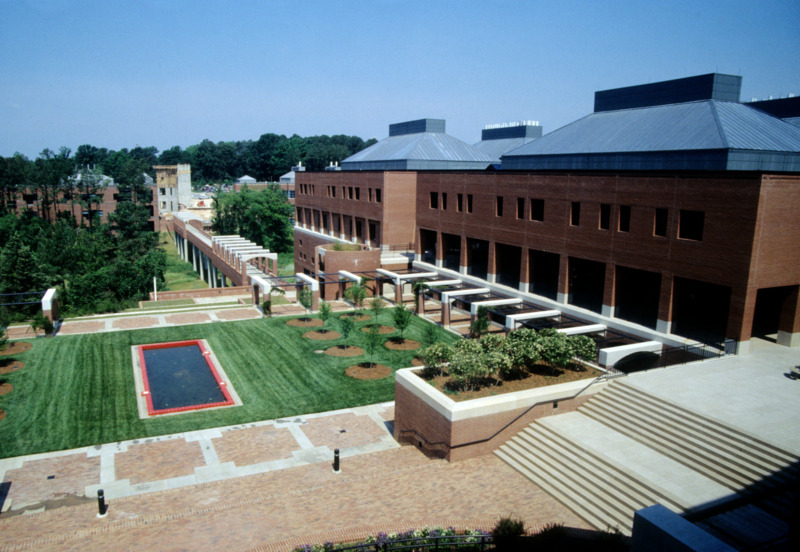

In [3]:
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg"]

for url in urls:
    image = io.imread(url)
    image2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    cv2_imshow(image2)
    

## Step3: Fourier Transform of Gray Images
[FFT](https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_transforms/py_fourier_transform/py_fourier_transform.html)
> A fourier transform is used to find the frequency domian of an image. You can consider an image as a signal which is sampled in two directions. So taking a fourier transform in both X and Y directions gives you the frequency representation of image. For the sinusoidal signal, if the amplitude varies so fast in short time, you can say it is a high frequency signal. If it varies slowly, it is a low frequency signal. Edges and noises are high frequency contents in an image because they change drastically in images.

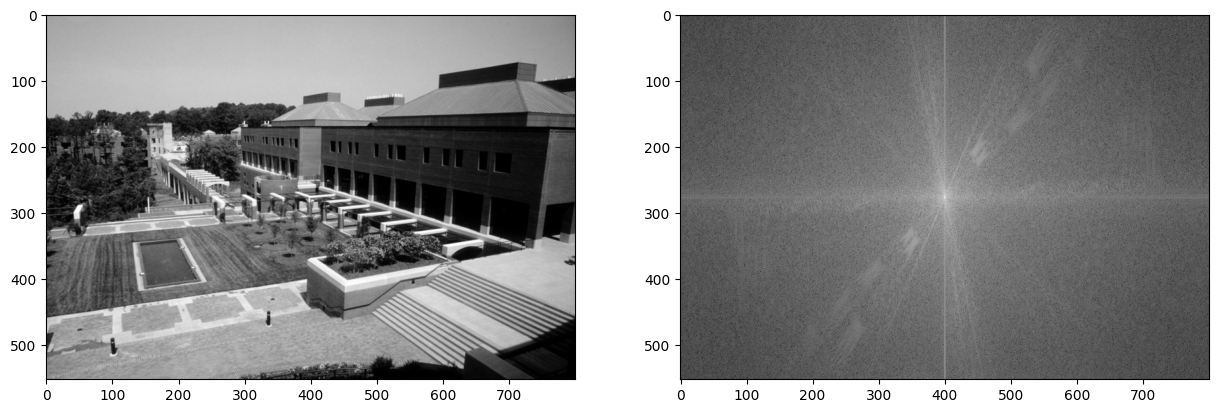

In [6]:
gray_image = cv.cvtColor(image2, cv.COLOR_RGB2GRAY)

imBlur = gray_image

f = np.fft.fft2(imBlur)

fshift = np.fft.fftshift(f)

magnitude_spectrum = 40 * np.log(np.abs(fshift))

plt.figure(figsize=(15,10))

plt.subplot(121), plt.imshow(imBlur, cmap='gray')
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
plt.show()

In [10]:
imBlur.shape, f.shape

((552, 800), (552, 800))

## Step4: Finding Edges by Highpass Filtering in FFT

> This section demonstrates conducting a high pass filter to remove the low frequency component, resulting in a sharpened image which contains the edges

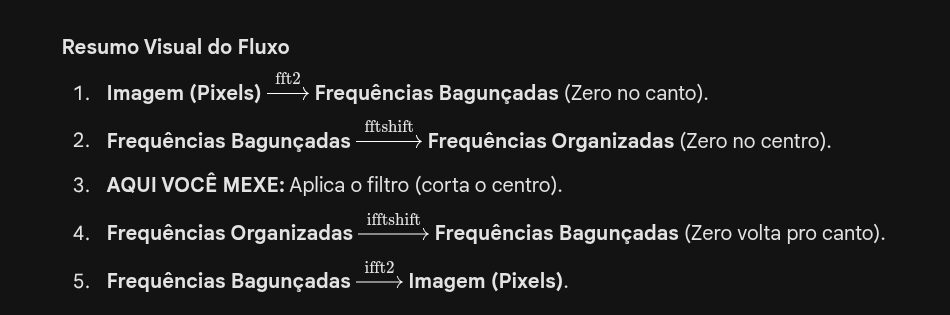

/tmp/ipython-input-360923853.py:10: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 30 * np.log(np.abs(fshift))


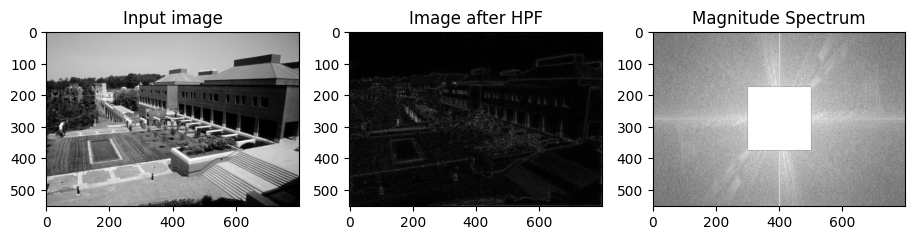

In [14]:
k = 100
rows, cols = imBlur.shape
crow, ccol = round(rows/2) , round(cols/2)

fshift[crow-k:crow + k, ccol-k:ccol +k] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

magnitude_spectrum = 30 * np.log(np.abs(fshift))

plt.figure(figsize=(15,10))
plt.subplot(141),plt.imshow(imBlur, cmap='gray')
plt.title('Input image')
plt.subplot(142),plt.imshow(1.6 * img_back, cmap='gray')
plt.title('Image after HPF')
plt.subplot(143),plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.show()

# Now, a lowpass filter

/tmp/ipython-input-2712526405.py:10: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 30 * np.log(np.abs(fshift))


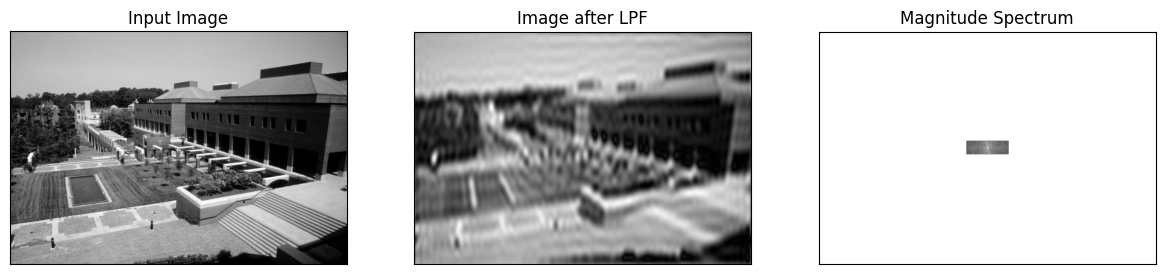

In [16]:
f = np.fft.fft2(imBlur)

fshift = np.fft.fftshift(f)
fshift[0:260, :] = 0
fshift[rows -260: rows, :] = 0
fshift[:,cols - 350: cols] = 0
fshift[:, 0:350] = 0

f_ishift = np.fft.ifftshift(fshift)
magnitude_spectrum = 30 * np.log(np.abs(fshift))
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)
plt.figure(figsize=([20, 20]))
plt.subplot(141),plt.imshow(imBlur, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(142),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after LPF'), plt.xticks([]), plt.yticks([])
plt.subplot(143),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()
